# 📏 Standardization — Why Scale the Data?

When features have different units and magnitudes, machine learning models 
can be misled — not because the data is wrong, but because the scale is unfair.

In this notebook we explore **StandardScaler** — what it does, why it matters, 
and where it breaks down — using a Social Network Ads dataset with two features: 
`Age` (18–60) and `EstimatedSalary` (15k–150k).

**What this notebook covers:**
- How StandardScaler transforms data and why fit/transform separation matters
- Visual proof that scaling preserves distribution shape
- Why scaling speeds up model convergence (Logistic Regression experiment)
- Why some models are completely unaffected (Decision Tree)
- How outliers corrupt StandardScaler — and what to use instead

> **Core idea:** scaling doesn't change what the data says — 
> it ensures every feature gets an equal hearing.

In [20]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
# ===========================================
# MODULE 1: IMPORTING DATASET
# ===========================================


#Import the data
df = pd.read_csv("../data/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [22]:
# Drop UserId and Gender as no effect 
df = df.iloc[:,2:]
df.sample(5)# check random 5 samples

,Age,EstimatedSalary,Purchased
203,41,71000,0
323,48,30000,1
286,37,62000,0
253,37,146000,1
366,58,47000,1


## ✂️ Module 2: Splitting Data

Data is split into **80% train / 20% test** using `train_test_split`.

**Why split before scaling?**  
The scaler must be fit **only on training data** — fitting on the full dataset would leak test information (mean and std would be influenced by test samples), giving an overly optimistic evaluation. This is called **data leakage**.

In [23]:
# ===============================
# MODULE 2: SPLITTING DATA
# ===============================

from sklearn.model_selection import train_test_split

X = df.drop('Purchased', axis=1) # axis = 1 (for column)
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of Training set X : {X_train.shape}")
print(f"Shape of Test set X : {X_test.shape}")


Shape of Training set X : (320, 2)
Shape of Test set X : (80, 2)


## ⚖️ Module 3: Standardization (StandardScaler)

StandardScaler transforms each feature to have **mean = 0** and **standard deviation = 1**:

$$z = \frac{x - \mu}{\sigma}$$




### What Standardization Does NOT Do

- ❌ Does not change the shape of the distribution (normal stays normal, skewed stays skewed)
- ❌ Does not remove outliers — extreme values remain extreme, just rescaled
- ❌ Does not make features independent of each other



In [24]:
# =============================================
# MODULE 3: STANDARDIZATION (StandardScaler)
# =============================================


from sklearn.preprocessing import StandardScaler

# Making an object of StandardScaler class
scaler = StandardScaler()

#fit the scaler to the train set (Evaluates Mean and Standard deviation)

scaler.fit(X_train) 
# USE scaler.var_ to calculate Variance of data

print("---"*20)
print(f"Mean of Age: {scaler.mean_[0]:.2f} ")
print(f"SD of Age : {scaler.scale_[0]:.2f}")

print("---"*20)
print(f"Mean of EstimatedSalary: ${scaler.mean_[1]:.2f}")
print(f"SD of EstimatedSalary : ${scaler.scale_[1]:.2f}")


------------------------------------------------------------
Mean of Age: 37.87 
SD of Age : 10.19
------------------------------------------------------------
Mean of EstimatedSalary: $70281.25
SD of EstimatedSalary : $34376.71



### Why Standardize?

Raw features in this dataset have a massive scale difference:

| Feature | Mean (μ) | Std Dev (σ) | Range |
|---|---|---|---|
| Age | ~38 | ~10 | 18 – 60 |
| EstimatedSalary | ~69,000 | ~34,000 | 15k – 150k |

The salary values are **~3000x larger** than age values. For algorithms that rely on 
distances or gradients, this means:
- Salary dominates every distance calculation — Age becomes almost irrelevant
- The gradient loss surface becomes elongated — optimizer overshoots in the Salary 
  direction and crawls in the Age direction
- The model effectively learns from one feature, ignoring the other

Standardization fixes this by putting both features on the same scale — neither 
dominates the other.

### Why fit() Only on Train Set?

```python
scaler.fit(X_train)        # ✅ learn mean & std from train only
scaler.transform(X_train)  # ✅ apply to train
scaler.transform(X_test)   # ✅ apply same transformation to test
scaler.fit(X_test)         # ❌ never do this
```

If `fit()` on the test set (or the full dataset), the scaler learns the mean and 
std of test data — information your model is not supposed to have during training. 
This is called **data leakage**.

The scaler fitted on train is applied **as-is** to the test set. The test set gets 
transformed using the train's mean and std — this simulates real deployment where 
new incoming data is scaled using statistics learned from historical training data.

> **Rule:** always `fit()` on train, `transform()` on both. Use `fit_transform()` 
on train as a shortcut — never on test.

In [25]:
# Transform train and test sets 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("preview : ",X_train_scaled[0]) # So the scaled output is Numpy's Arrays 

# Covert both scaled values into pandas dataframe 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled.head()

preview :  [-1.06675246 -0.38634438]


,Age,EstimatedSalary
0,-1.066752,-0.386344
1,0.797535,-1.229939
2,0.110692,1.853544
3,0.601294,-0.909955
4,1.876859,-1.288118


In [26]:
# Info Of Data
# Before Scaling 
X_train.describe().round(1)

,Age,EstimatedSalary
count,320.0,320.0
mean,37.9,70281.2
std,10.2,34430.6
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [27]:
# After Scaling 
X_train_scaled.describe().round(1)

# Mean = 0 and SD = 1

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


## 📊 Module 4: Effect of Scaling on Data Distribution

Before jumping into model training, it's important to visually verify what 
standardization actually does to the data — and what it doesn't.

We examine this through two types of plots:
1. **Scatter Plot** — how the joint distribution of Age vs Salary changes
2. **KDE Plot** — how the individual feature distributions change

These plots answer a critical question: *does scaling distort the data or just rescale it?*

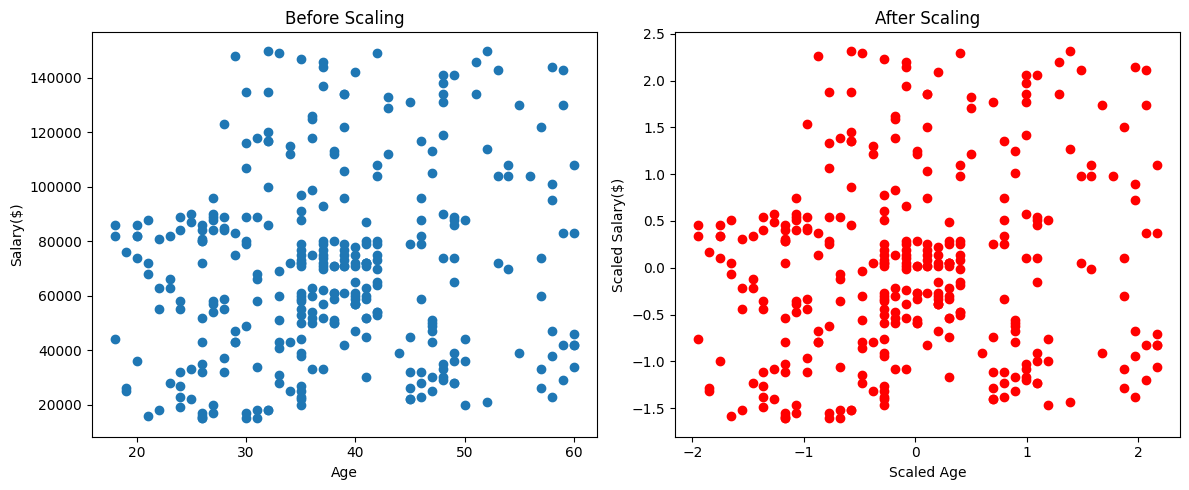

In [28]:
# ==============================
# MODULE 4: EFFECT OF SCALING
# ==============================

# 1. Spread of data

fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
axis1.scatter(X_train['Age'], X_train['EstimatedSalary'])
axis1.set_xlabel("Age")
axis1.set_ylabel("Salary($)")
axis1.set_title("Before Scaling")

# After Scaling
axis2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color = 'red')
axis2.set_xlabel("Scaled Age")
axis2.set_ylabel("Scaled Salary($)")
axis2.set_title("After Scaling")

plt.tight_layout()
plt.show()

### 4.1 Scatter Plot — Joint Distribution of Age vs Salary

| | Before Scaling | After Scaling |
|---|---|---|
| X-axis range | 18 – 60 | -2 – 2 |
| Y-axis range | 20,000 – 150,000 | -1.5 – 2.5 |
| Center | (38, 69k) | (0, 0) |

**What changed:**
- Both axes are now on the same scale — centered at 0
- The data cloud is re-centered to the origin (mean = 0)
- Most points fall within the **-2 to +2 range** (within 2 standard deviations — expected for normal-ish data)

**What did NOT change:**
- The **shape and spread** of the point cloud is identical — same clusters, same gaps, same pattern
- The **relationship** between Age and Salary is fully preserved
- No data point moved relative to another — only the coordinate system changed

> Scaling is just a change of units — like converting km to miles. 
> The map looks different but the terrain is the same.

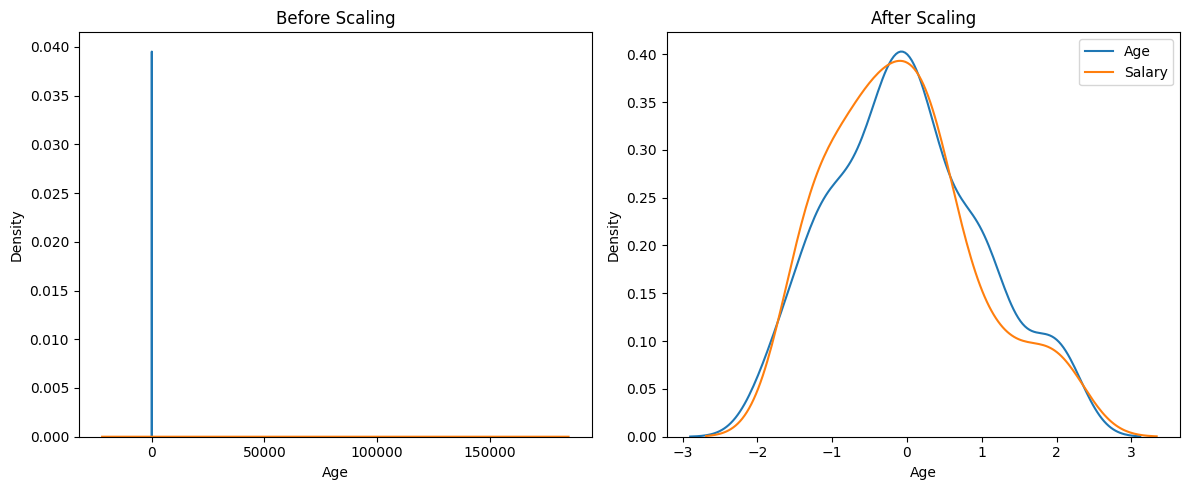

In [29]:
# 2. Kernel Density Estimate (KDE) 

fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(12,5))
# Before Scaling
sns.kdeplot(X_train['Age'], ax=axis1)
sns.kdeplot(X_test['EstimatedSalary'], ax=axis1)
axis1.set_title("Before Scaling")

sns.kdeplot(X_train_scaled['Age'], ax=axis2, label='Age')
sns.kdeplot(X_test_scaled['EstimatedSalary'], ax=axis2, label='Salary')
axis2.set_title("After Scaling")

plt.tight_layout()
plt.legend()
plt.show()

### 4.2 KDE Plot — Comparing Both Features on Same Axis

KDE (Kernel Density Estimate) shows the probability distribution of a feature — 
essentially a smoothed histogram.

**Before Scaling:**
- Age (range ~18–60) and Salary (range ~20k–150k) plotted on the same axis
- Salary is spread across 0–150,000 while Age is squeezed near 0 — it looks like 
  a vertical spike because Age values are tiny compared to Salary's scale
- **You cannot visually compare two features with different units on the same axis**

**After Scaling:**
- Both features now live on the same -3 to +3 range
- You can finally compare their distributions side by side:
  - Both are approximately **bell-shaped (normal-like)** — peaked near 0
  - Salary (orange) has a slightly **heavier right tail** — some high earners pulling it right
  - Age (blue) is slightly more **symmetric**

**The key insight this plot demonstrates:**
The distributions of Age and Salary were always similar in shape — 
we just couldn't see it because the scales were incomparable. 
Scaling makes the comparison honest.

> Before scaling: Salary was drowning out Age visually and mathematically.  
> After scaling: both features contribute equally — to the plot and to the model.

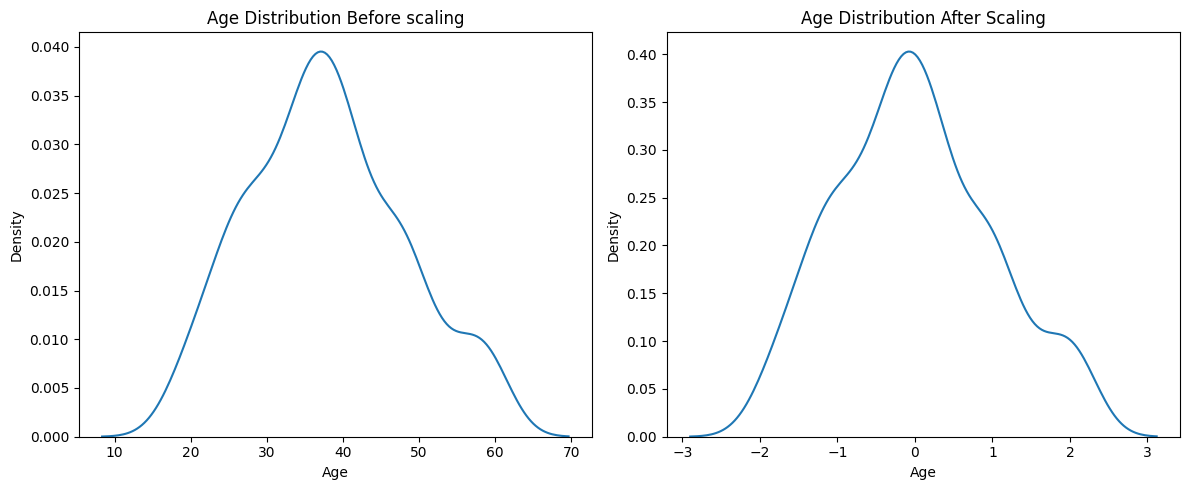

In [30]:
# 3. Kernel Density Estimate (KDE) for Age -- characteristic plot remains the same
fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling 
sns.kdeplot(X_train['Age'], ax=axis1)
axis1.set_title("Age Distribution Before scaling")


# After scaling 
sns.kdeplot(X_train_scaled['Age'], ax=axis2)
axis2.set_title('Age Distribution After Scaling')


plt.tight_layout()
plt.show()


### 4.3 KDE — Age Distribution Before vs After Scaling

The curve is **identical in shape** — just the x-axis changed from raw units (10–70) 
to standardized units (-3 to +3), centered at 0.

Both plots show the same characteristics:
- Peak around age 38 (= 0 after scaling)
- Slight **secondary bump** around age 55–60 (= ~2 after scaling) — visible in both
- Right-skewed tail

> StandardScaler only shifts and rescales — it never touches the shape. 
> Same data, different ruler.

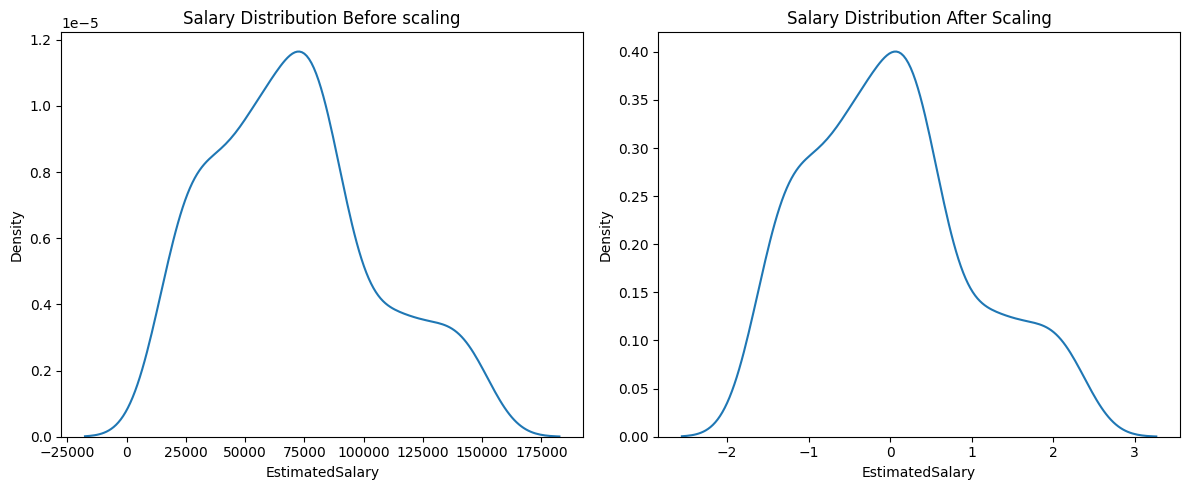

In [31]:
# 4. Kernel Density Estimate (KDE) for EstimatedSalary -- characteristic plot remains the same

fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling 
sns.kdeplot(X_train['EstimatedSalary'], ax=axis1)
axis1.set_title("Salary Distribution Before scaling")


# After scaling 
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=axis2)
axis2.set_title('Salary Distribution After Scaling')


plt.tight_layout()
plt.show()

### 4.4 KDE — Salary Distribution Before vs After Scaling

Again, **identical shape** — only the axis rescaled from raw dollars (0–175k) 
to standardized units (-2 to +3), centered at 0.

Both plots show:
- Peak around ₹75,000 (= 0 after scaling)
- **Prominent secondary bump** on the right (~125k = ~1.5 after scaling) — 
  a cluster of high earners clearly visible in both
- Heavier right tail compared to Age distribution

**Notice the y-axis before scaling:** `1e-5` — density values are tiny because 
salary values are huge. After scaling the y-axis reads normally (0 to 0.4), 
making it directly comparable to the Age KDE in 4.3.

> This confirms the Module 3 rule: StandardScaler preserves all distributional 
> information — shape, skew, peaks, tails. It only changes the coordinate system.

## 🤖 Module 5: Effect of Scaling on Model Accuracy

### Theory — Why Logistic Regression Needs Scaling

Logistic regression finds the decision boundary by minimizing a loss function 
using **gradient descent**. The optimizer iteratively takes steps toward the minimum.

The shape of the loss surface depends directly on feature scales:

**Without scaling** (Age: 18–60, Salary: 15k–150k):
- The loss surface is a **elongated ellipse** — steep in the Salary direction, 
  flat in the Age direction
- Gradient descent overshoots along Salary and crawls along Age
- Needs many iterations to zigzag its way to the minimum

**With scaling** (both features: -3 to +3):
- The loss surface is more **circular** — equal curvature in all directions
- Gradient descent moves directly toward the minimum
- Converges in far fewer iterations

In [39]:
# =================================================
# MODULE 5: EFFECT OF SCALING ON MODEL'S ACCURACY
# =================================================

# 1. Distance Based Model (Logistic Regression)

import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    
    print(f"{'Iterations':<15} {'Raw Acc':<15} {'Scaled Acc':<15} {'Raw Converged?'}")
    print("-" * 60)
    
    for i in iterations:
        
        lr_raw = LogisticRegression(max_iter=i)
        lr_scaled = LogisticRegression(max_iter=i)
        
        lr_raw.fit(X_train, y_train)
        lr_scaled.fit(X_train_scaled, y_train)
        
        converged = lr_raw.n_iter_[0] < i  # True if converged before limit
        
        acc_raw = accuracy_score(y_test, lr_raw.predict(X_test))
        acc_scaled = accuracy_score(y_test, lr_scaled.predict(X_test_scaled))
        
        print(f"{i:<15} {acc_raw:<15} {acc_scaled:<15} {str(converged):<15}")

Iterations      Raw Acc         Scaled Acc      Raw Converged?
------------------------------------------------------------
10              0.65            0.8625          False          
50              0.875           0.8625          False          
100             0.8875          0.8625          True           
200             0.8875          0.8625          True           
500             0.8875          0.8625          True           


### What This Experiment Tests

By limiting `max_iter`, we force the optimizer to stop early — 
exposing how fast each model converges:
- **Low iterations** → does scaled data reach good accuracy faster?
- **`n_iter_[0] < max_iter`** → True means converged before hitting the limit (healthy)
- **ConvergenceWarning** → solver hit the wall without converging (bad)


- Scaled model hits full accuracy at **< 50 iterations** and stays there
- Raw model needs **100+ iterations** to converge — sklearn itself warns *"scale your data"*
- Final accuracy looks similar only because we eventually give raw data enough iterations

> **Key takeaway:** scaling doesn't always change final accuracy — 
> it changes **how efficiently** the model gets there. 
> In production with large datasets, convergence speed is not a luxury, it's a necessity.

### 5.2 Decision Tree — Scale Invariant Model

### Theory — Why Decision Trees Don't Need Scaling

Decision trees split data by asking threshold questions:

```
Is Age > 40?
├── Yes → Is Salary > 80,000? → ...
└── No → Is Salary > 60,000? → ...
```

Each split looks at **one feature at a time** and finds the best threshold — 
it never computes distances or gradients between features. 
The actual numeric values don't matter, only the **order and relative ranking** does.

**Scaling changes the values but never the order:**
- Age 25 < Age 40 before scaling → -1.3 < 0.2 after scaling ✓ same order
- The best split threshold just gets re-expressed in new units — the tree structure is identical



In [ ]:
# 2. Decision Tree 

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scaled, y_train)

y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

# comparing the accuracy of both cases
acc_raw = accuracy_score(y_test, y_pred)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"Accuracy of Actual Data : {acc_raw}")
print(f"Accuracy of Scaled Data : {acc_scaled }")

if np.equal(acc_raw, acc_scaled):
    print("No Effect of scaling!")

Accuracy of Actual Data : 0.8375
Accuracy of Scaled Data : 0.8375
No Effect of scaling!


Both accuracies are exactly equal — confirming the theory.

### Algorithms That DO vs DON'T Need Scaling

| Needs Scaling ✅ | Scale Invariant ❌ |
|---|---|
| Logistic Regression | Decision Tree |
| KNN | Random Forest |
| SVM | XGBoost / LightGBM |
| Neural Networks | Naive Bayes |
| PCA | |

> **Rule of thumb:** if the algorithm uses distances, dot products, or gradient 
> descent — scale. If it uses thresholds and splits — don't bother.

## ⚠️ Module 6: Effect of Outliers on StandardScaler

### Theory — Why Outliers Break StandardScaler

StandardScaler computes **mean (μ)** and **standard deviation (σ)** from the data. 
Both of these statistics are sensitive to extreme values:

- A single outlier pulls the mean toward itself
- It inflates the standard deviation
- After scaling, all normal points get compressed into a tiny range while 
  the outlier still sits far out

**Example — what one outlier does:**
```
Normal data: [20, 25, 30, 35, 40] → mean=30, std=7.9
With outlier: [20, 25, 30, 35, 300] → mean=82, std=109
```

After scaling with outlier present, values 20–40 all compress near -0.5 to -0.4 — 
the model can barely distinguish between them.

### What Was Done Here

Three extreme outliers were injected into the dataset:

| Age | Salary | Purchased |
|---|---|---|
| 15 | 200,000 | 0 |
| 90 | 250,000 | 1 |
| 95 | 300,000 | 1 |

These are far outside the normal range (Age: 18–60, Salary: 15k–150k) — 
enough to noticeably shift the mean and inflate the std.

### The Fix — RobustScaler

`RobustScaler` uses **median** and **IQR (interquartile range)** instead:

$$z = \frac{x - \text{median}}{IQR}$$

Median and IQR are resistant to outliers — extreme values don't affect them.

| | StandardScaler | RobustScaler |
|---|---|---|
| Center | Mean | Median |
| Scale | Std Dev | IQR (Q3 - Q1) |
| Outlier Sensitive | ❌ Yes | ✅ No |
| Use When | Clean data | Outliers present |



> **Rule:** always visualize your data before choosing a scaler. 
> KDE and boxplots will reveal outliers — let them guide your choice.

In [41]:
# ===============================
# MODULE 6: EFFECT OF OUTLIERS 
# ===============================

# Adding Outliers in the data 
outliers = pd.DataFrame({
    'Age' : [15 ,90, 95],
    'EstimatedSalary' : [200000, 250000, 300000],
    'Purchased' : [0.0 ,1.0, 1.0]

})

# Append the data 
df = pd.concat([df, outliers], ignore_index=True)
#df = df.drop(columns=['User ID', 'Gender'])
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0.0
1,35,20000,0.0
2,26,43000,0.0
3,27,57000,0.0
4,19,76000,0.0


In [ ]:


from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),df['Purchased'] , test_size=0.2, random_state=42)
print(f"Shape of Training set X : {X_train.shape}")
print(f"Shape of Test set X : {X_test.shape}")

Scaler = StandardScaler()

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Covert both scaled values into pandas dataframe 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)



Shape of Training set X : (322, 2)
Shape of Test set X : (81, 2)


In [49]:

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    
    print(f"{'Iterations':<15} {'Raw Acc':<15} {'Scaled Acc':<15} {'Raw Converged?'}")
    print("-" * 60)
    
    for i in iterations:
        
        lr_raw = LogisticRegression(max_iter=i)
        lr_scaled = LogisticRegression(max_iter=i)
        
        lr_raw.fit(X_train, y_train)
        lr_scaled.fit(X_train_scaled, y_train)
        
        converged = lr_raw.n_iter_[0] < i  # True if converged before limit
        
        acc_raw = accuracy_score(y_test, lr_raw.predict(X_test))
        acc_scaled = accuracy_score(y_test, lr_scaled.predict(X_test_scaled))
        
        print(f"{i:<15} {acc_raw:<15.3f} {acc_scaled:<15.3f} {str(converged):<15}")

Iterations      Raw Acc         Scaled Acc      Raw Converged?
------------------------------------------------------------
10              0.630           0.864           False          
50              0.877           0.864           False          
100             0.864           0.864           True           
200             0.864           0.864           True           
500             0.864           0.864           True           


### Result Analysis — Convergence Table (With Outliers)

| Iterations | Raw Acc | Scaled Acc | Raw Converged? |
|---|---|---|---|
| 10 | 0.630 | 0.864 | False |
| 50 | 0.877 | 0.864 | False |
| 100 | 0.864 | 0.864 | True |
| 200 | 0.864 | 0.864 | True |
| 500 | 0.864 | 0.864 | True |

**What the outliers changed vs the clean dataset:**
- Raw model at iter=50 jumped to **0.877** — higher than scaled (0.864)
- This is the outlier effect: injected points shifted the decision boundary 
  slightly, accidentally benefiting the raw model at that iteration
- But raw still **failed to converge** at iter=50 (False) — a lucky accuracy 
  on an unconverged model is not reliable

**What remained the same:**
- Scaled model hit 0.864 at iter=10 and **never moved** — stable and converged immediately
- Raw model still needed 100 iterations to converge and stabilize
- Once both converged (iter=100+), scores are identical — confirming outliers 
  didn't add real signal, just noise

**The danger of outliers with StandardScaler:**
The 3 injected extreme salaries (200k–300k) inflated the std of Salary — 
compressing all normal salary values closer together after scaling. 
The scaled model still performed well here because logistic regression 
is relatively robust, but on a more complex dataset this compression 
would meaningfully hurt the scaled model's accuracy.

> **Takeaway:** outliers don't just affect accuracy — they corrupt the 
> scaler itself. Always handle outliers before scaling, or switch to RobustScaler.

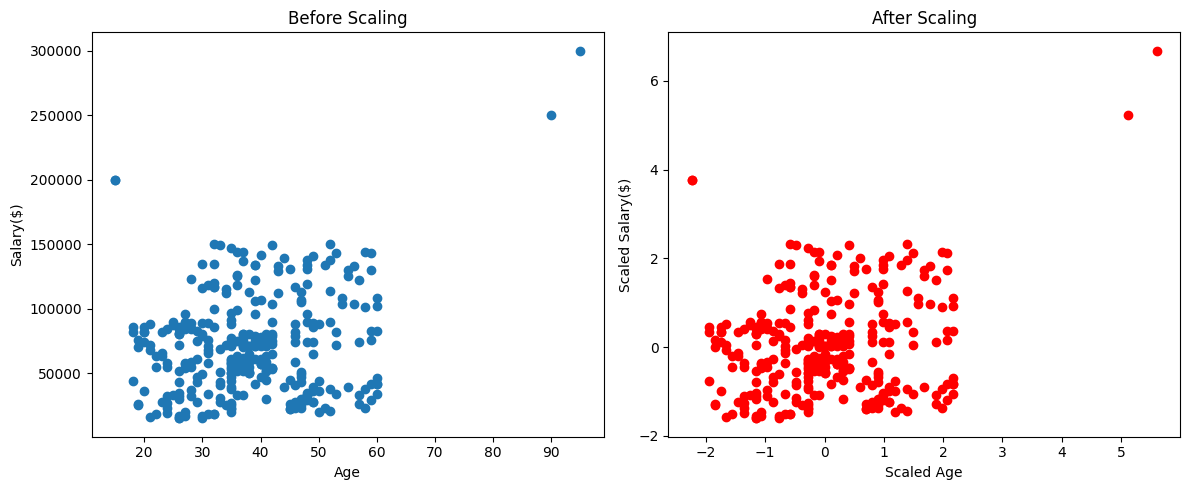

In [18]:
# Scatter Plot showing Outliers remains same 

fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
axis1.scatter(X_train['Age'], X_train['EstimatedSalary'])
axis1.set_xlabel("Age")
axis1.set_ylabel("Salary($)")
axis1.set_title("Before Scaling")

# After Scaling
axis2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color = 'red')
axis2.set_xlabel("Scaled Age")
axis2.set_ylabel("Scaled Salary($)")
axis2.set_title("After Scaling")

plt.tight_layout()
plt.show()

### 6.1 Scatter Plot — Outlier Effect on Scaling

**Before scaling:** 3 outliers are visible but the normal cluster (Age 18–60, 
Salary 20k–150k) is well spread and readable.

**After scaling:** the entire normal cluster gets **crushed into a tiny region** 
around (0,0) — because StandardScaler inflated std to accommodate the outliers 
at age 90–95 and salary 200k–300k, leaving almost no separation among normal points.

> The 3 outliers didn't just sit far away — they corrupted the scale for 
> every other point. Use **RobustScaler** when outliers are present.